In [1]:
import pandas as pd
import numpy as np 

# Importations pour la construction du modèle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Lambda

# Importation pour la transformation sur les images
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation

# Importation pour utiliser un modèle pre entrainé
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from keras.optimizers import Adam

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation pour les visualisations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from metrics import MacroMetricsCallback

from sklearn.utils.class_weight import compute_class_weight

#from models.gradcam import GradCAM
#from models.gradcam import show_gradcam

#import random

print("Opération terminée")

Opération terminée


1. Chargement des images

In [2]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_split"

train_ds = image_dataset_from_directory(
    directory=chemin+"/train_augmented/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='rgb' 
)

test_ds = image_dataset_from_directory(
    directory=chemin+"/test/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
   color_mode='rgb'
    
)

val_ds = image_dataset_from_directory(
    directory=chemin+"/validation/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
    
)


Found 33336 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


2026-07-25 14:54:40.693843: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-07-25 14:54:40.693897: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-25 14:54:40.693901: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1784984080.694151  312262 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784984080.694336  312262 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 2083 files belonging to 4 classes.


In [3]:
print(train_ds.class_names)
print(val_ds.class_names)
print(test_ds.class_names)

for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Images : (32, 224, 224, 3)
Labels : (32,)


2026-07-25 14:54:42.331431: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
#Prétraitement des images pour la compatibilité avec le modèle EfficienNet
train_ds=train_ds.map(lambda x,y: (preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y: (preprocess_input(x),y))
tes_ds=test_ds.map(lambda x,y: (preprocess_input(x),y))

In [5]:
for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

Images : (32, 224, 224, 3)
Labels : (32,)


2026-07-25 14:54:48.753575: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2. Visualisation du jeu de données

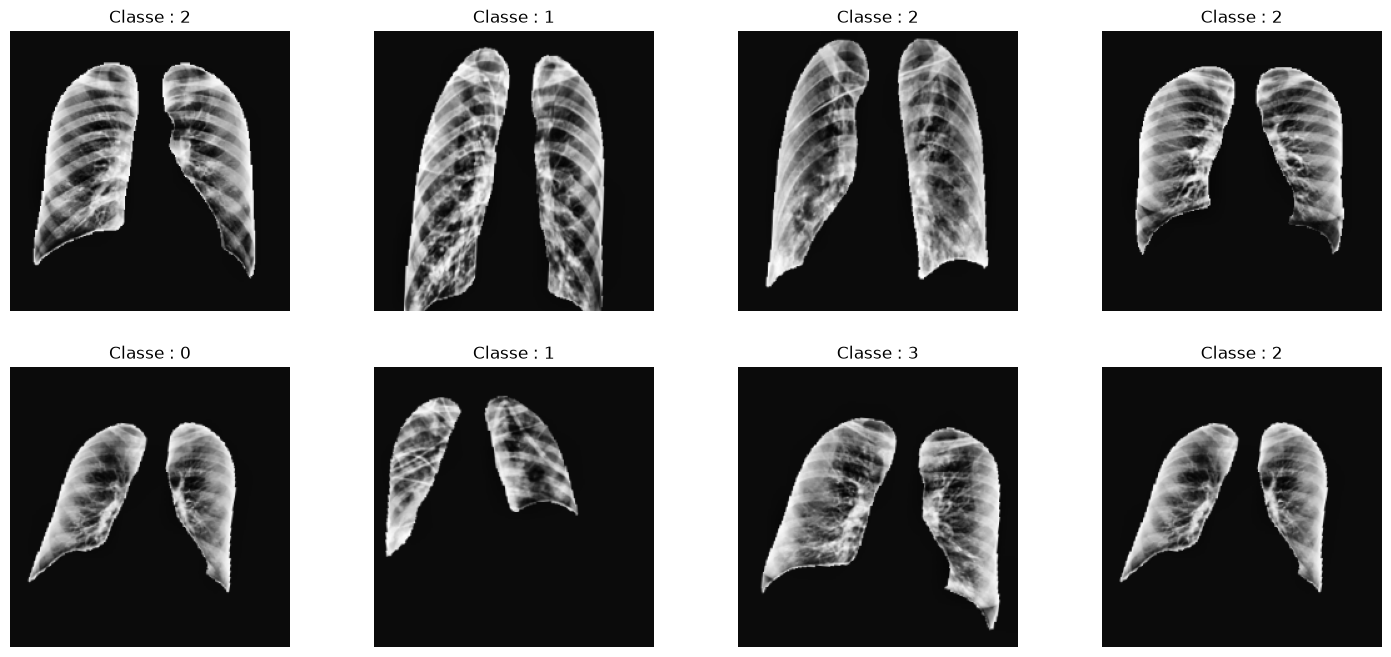

In [6]:
number_of_image=8

fig=plt.figure (figsize=(18,8))

for images, label in train_ds.take(1):
    for i in range(number_of_image):
        plt.subplot(2,4,i+1)
        indice=np.random.randint(len(label))
        plt.imshow(images[indice].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(f"Classe : {label[i].numpy()}")


plt.show()

3. Chargement du modèle

In [7]:
#Choix du device
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
base_model=EfficientNetB0(weights="imagenet", include_top=False)

#Gel des couches

base_model.trainable = False

base_model

<Functional name=efficientnetb0, built=True>

In [9]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
inputs=Input(shape=(224, 224, 3), name="Input")

x=base_model(inputs)

x=GlobalAveragePooling2D()(x)
x=Dropout(0.3)(x)
x=Dense(units=128, activation="relu")(x)
x=Dropout(0.3)(x)
outputs=Dense(units=4, activation="softmax", name="output_layer")(x)

model=Model(inputs=inputs, outputs=outputs)

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

4. Création de callbacks et d'un early stopping

In [12]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=5,
                             min_delta=0.01,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [13]:
#Création d'une fonction pour suivre le f1-score à chaque epoch
from metrics import MacroMetricsCallback

macro_metrics = MacroMetricsCallback(train_ds, val_ds)
    

5. Compilation et entraînement du modèle

In [14]:
optimizer=Adam(1e-4)

In [15]:
#Compilation du modèle

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [16]:
#Entraînement du modèle

model_history=model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

Epoch 1/30


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-25 15:23:37.581017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6749 - loss: 0.8214

2026-07-25 15:33:38.691540: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7377 | Val F1 : 0.7230
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 623s 593ms/step - accuracy: 0.6749 - loss: 0.8214 - val_accuracy: 0.7849 - val_loss: 0.5649 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7377 - val_f1_macro: 0.7230
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.7371 - loss: 0.6723
Train F1 : 0.7652 | Val F1 : 0.7491
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 574s 551ms/step - accuracy: 0.7371 - loss: 0.6723 - val_accuracy: 0.7969 - val_loss: 0.5303 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7652 - val_f1_macro: 0.7491
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7504 - loss: 0.6379

2026-07-25 15:53:36.575156: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7747 | Val F1 : 0.7698
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 629s 604ms/step - accuracy: 0.7504 - loss: 0.6379 - val_accuracy: 0.8104 - val_loss: 0.5002 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7747 - val_f1_macro: 0.7698
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7640 - loss: 0.6082
Train F1 : 0.7873 | Val F1 : 0.7813
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 665s 639ms/step - accuracy: 0.7640 - loss: 0.6082 - val_accuracy: 0.8147 - val_loss: 0.4866 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7873 - val_f1_macro: 0.7813
Epoch 5/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7698 - loss: 0.5939
Train F1 : 0.7934 | Val F1 : 0.7925
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 580s 557ms/step - accuracy: 0.7698 - loss: 0.5939 - val_accuracy: 0.8209 - val_loss: 0.4761 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7934 - val_f1_macro: 0.7925
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.7732 - loss: 0.5821
Train F1 : 0.7990 | Val 

2026-07-25 16:33:44.392993: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7940 | Val F1 : 0.7920
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 585s 562ms/step - accuracy: 0.7779 - loss: 0.5732 - val_accuracy: 0.8205 - val_loss: 0.4778 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7940 - val_f1_macro: 0.7920
Epoch 8/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7819 - loss: 0.5650
Train F1 : 0.8009 | Val F1 : 0.7944
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 583s 560ms/step - accuracy: 0.7819 - loss: 0.5650 - val_accuracy: 0.8214 - val_loss: 0.4672 - learning_rate: 1.0000e-04 - train_f1_macro: 0.8009 - val_f1_macro: 0.7944
Epoch 9/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7837 - loss: 0.5586
Train F1 : 0.7952 | Val F1 : 0.7917
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 608s 583ms/step - accuracy: 0.7837 - loss: 0.5586 - val_accuracy: 0.8224 - val_loss: 0.4700 - learning_rate: 1.0000e-05 - train_f1_macro: 0.7952 - val_f1_macro: 0.7917
Epoch 10/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7829 - loss: 0.5582
Train F1 : 0.7961 | Val

In [17]:
model.save("cnn_EfficientNet.keras")
model.save_weights("cnn_EfficientNet.weights.h5")
print("modèle et poids sauvegardés")

modèle et poids sauvegardés


6. Évaluation du modèle

In [18]:
train_acc=model_history.history["accuracy"]
val_acc=model_history.history["val_accuracy"]

train_loss=model_history.history["loss"]
val_loss=model_history.history["val_loss"]

train_f1=model_history.history["train_f1_macro"]
val_f1=model_history.history["val_f1_macro"]

nb_epochs=len(train_acc)
print(nb_epochs)

10


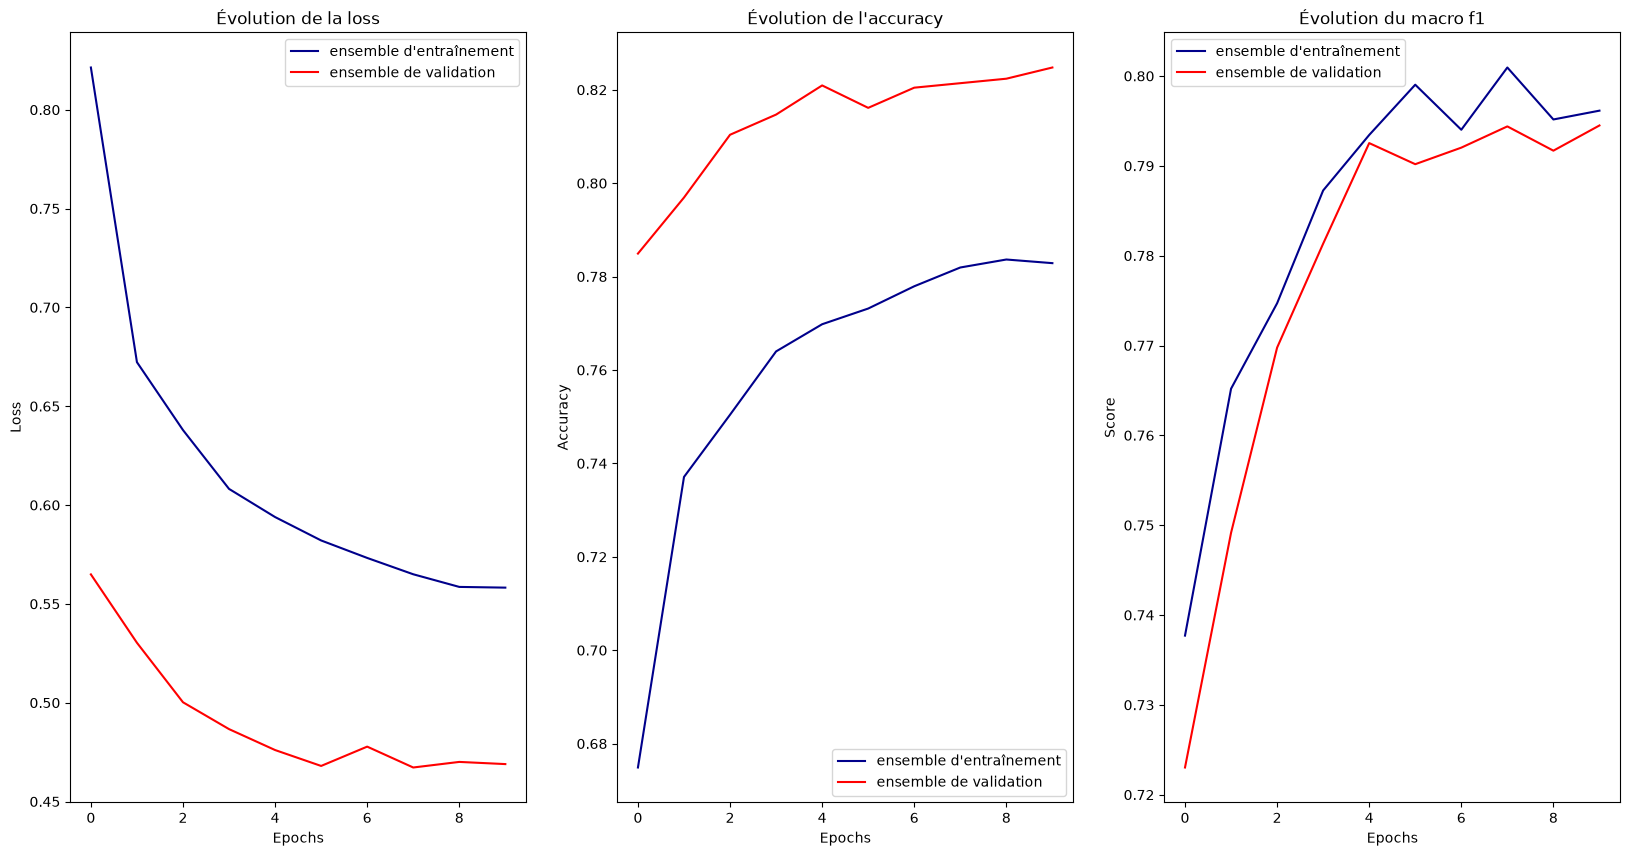

In [19]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [29]:
import pickle

with open("history_EfficientNet.pkl", "wb") as f:
    pickle.dump(model_history.history, f)

In [20]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step


In [21]:
y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

[0 0 0 ... 3 3 3]


In [22]:
print(classification_report(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.79      0.54      0.64       337
           1       0.82      0.79      0.80       599
           2       0.83      0.95      0.89      1014
           3       0.94      0.87      0.90       134

    accuracy                           0.83      2084
   macro avg       0.84      0.79      0.81      2084
weighted avg       0.83      0.83      0.82      2084



[[181  66  90   0]
 [ 37 473  89   0]
 [ 12  35 959   8]
 [  0   3  14 117]]


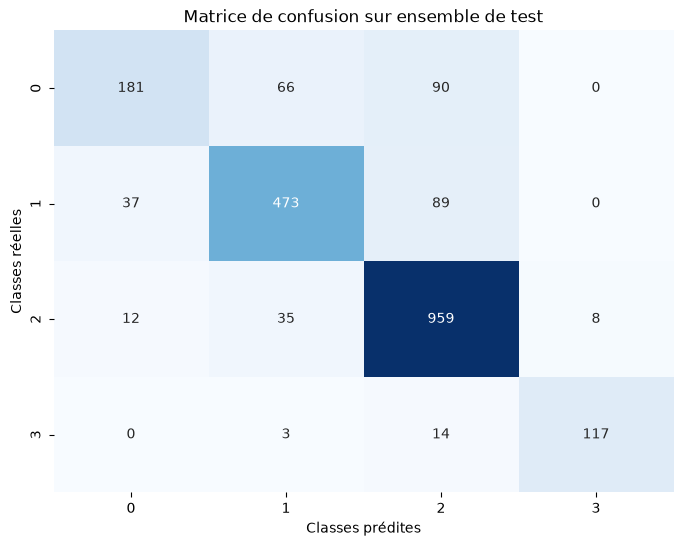

In [30]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)
    
print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

np.save("CM_EfficientNet.npy", conf_matrix)

7. Fine tuning

In [24]:
#Degel des couches inférieures : On ne dégel que le dernier bloc de convolution (block7a)
for i, layer in enumerate(base_model.layers):
    if layer.name.startswith('block7'):
            break
    freeze_from = i
for layer in model.layers[freeze_from:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [25]:
base_model.trainable = True

for layer in base_model.layers:

    if layer.name.startswith("block7"):
        break

    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

for layer in base_model.layers[-20:]:
    print(layer.name, layer.trainable)

block6d_project_conv False
block6d_project_bn False
block6d_drop False
block6d_add False
block7a_expand_conv True
block7a_expand_bn False
block7a_expand_activation True
block7a_dwconv True
block7a_bn False
block7a_activation True
block7a_se_squeeze True
block7a_se_reshape True
block7a_se_reduce True
block7a_se_expand True
block7a_se_excite True
block7a_project_conv True
block7a_project_bn False
top_conv True
top_bn False
top_activation True


In [26]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=8,
                             min_delta=0.001,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [27]:
fine_tuned_history=model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

model.save("cnn_fine_tuned_EfficientNet.keras")
print("fine tuned modèle sauvegardé")

Epoch 1/30


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.7880 - loss: 0.5572
Train F1 : 0.8111 | Val F1 : 0.8098
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 626s 596ms/step - accuracy: 0.7880 - loss: 0.5572 - val_accuracy: 0.8334 - val_loss: 0.4510 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8111 - val_f1_macro: 0.8098
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.7960 - loss: 0.5431
Train F1 : 0.8183 | Val F1 : 0.8122
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 622s 597ms/step - accuracy: 0.7960 - loss: 0.5431 - val_accuracy: 0.8358 - val_loss: 0.4440 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8183 - val_f1_macro: 0.8122
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8002 - loss: 0.5340
Train F1 : 0.8237 | Val F1 : 0.8126
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 609s 584ms/step - accuracy: 0.8002 - loss: 0.5340 - val_accuracy: 0.8373 - val_loss: 0.4383 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8237 - val_f1_macro: 0.8126
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━

2026-07-25 17:47:45.689067: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8050 - loss: 0.5159
Train F1 : 0.8364 | Val F1 : 0.8206
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 602s 578ms/step - accuracy: 0.8050 - loss: 0.5159 - val_accuracy: 0.8421 - val_loss: 0.4170 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8364 - val_f1_macro: 0.8206
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8091 - loss: 0.5079
Train F1 : 0.8378 | Val F1 : 0.8253
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 691s 663ms/step - accuracy: 0.8091 - loss: 0.5079 - val_accuracy: 0.8440 - val_loss: 0.4178 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8378 - val_f1_macro: 0.8253
Epoch 7/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8133 - loss: 0.4939
Train F1 : 0.8401 | Val F1 : 0.8288
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 836s 802ms/step - accuracy: 0.8133 - loss: 0.4939 - val_accuracy: 0.8483 - val_loss: 0.4172 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8401 - val_f1_macro: 0.8288
Epoch 8/30
1042/1042 ━━━━━━━━━━━━━━━

2026-07-25 20:57:39.084543: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


fine tuned modèle sauvegardé


8. Évaluation du modèle après fine tuning

In [31]:
train_acc_fine=fine_tuned_history.history["accuracy"]
val_acc_fine=fine_tuned_history.history["val_accuracy"]

train_loss_fine=fine_tuned_history.history["loss"]
val_loss_fine=fine_tuned_history.history["val_loss"]

train_f1_fine=fine_tuned_history.history["train_f1_macro"]
val_f1_fine=fine_tuned_history.history["val_f1_macro"]

nb_epochs_fine=len(train_acc_fine)
print(nb_epochs_fine)
print(np.arange(nb_epochs_fine)+nb_epochs)

20
[10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29]


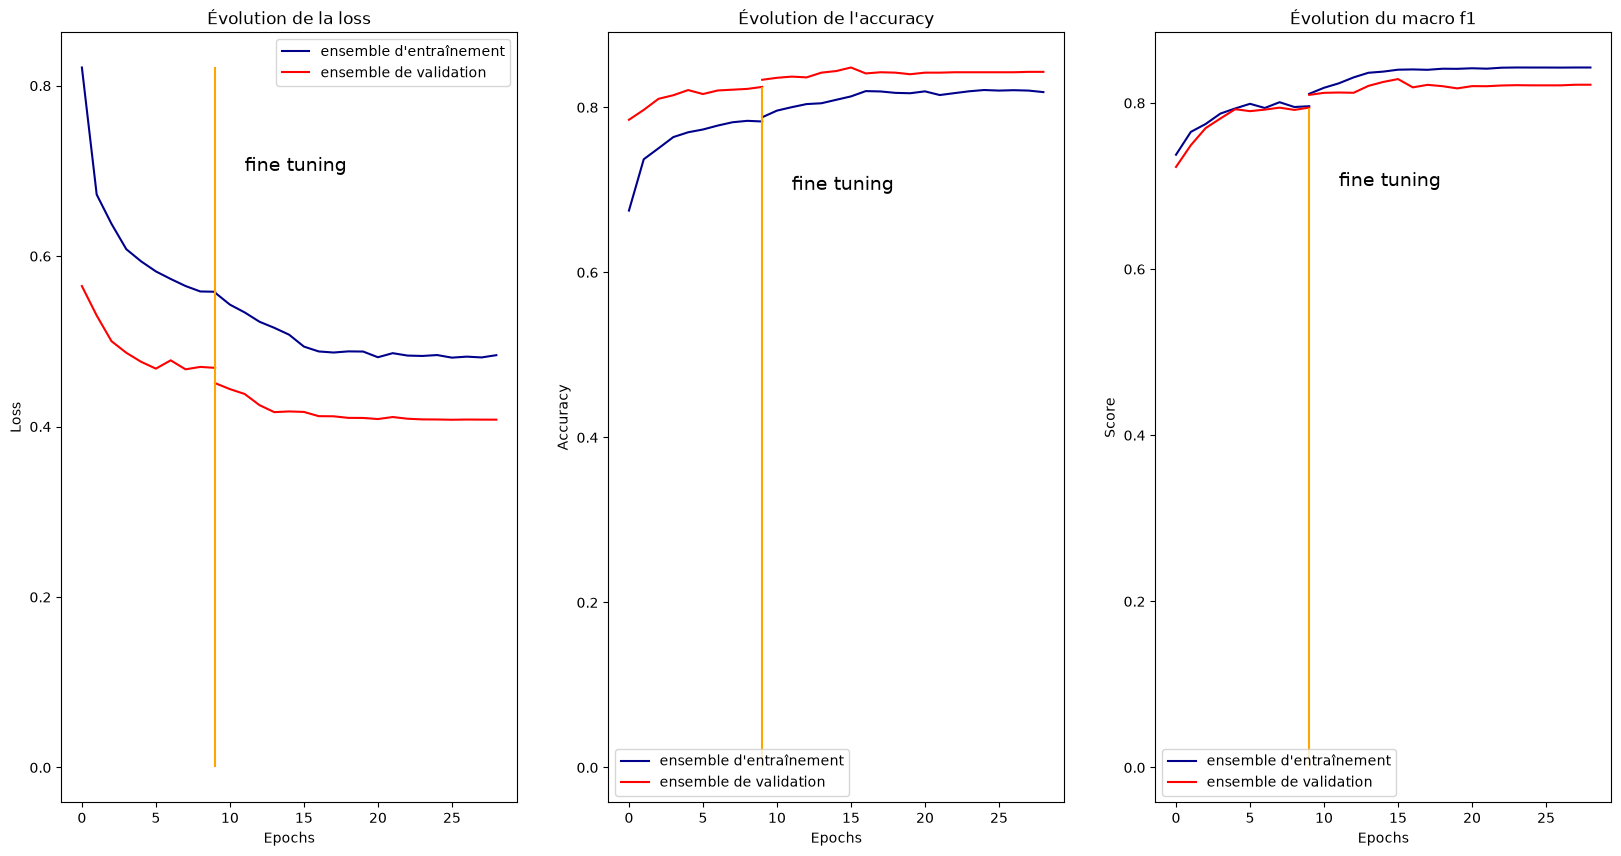

In [32]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_loss_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_loss_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(train_loss), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_acc_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_acc_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(val_acc), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, train_f1_fine, color="darkblue")
plt.plot(np.arange(nb_epochs_fine)+nb_epochs-1, val_f1_fine, color="red")

plt.vlines(nb_epochs-1, 0, max(val_f1), color="orange")
plt.text(nb_epochs+1, 0.7, "fine tuning", fontsize=14)

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [34]:
with open("history_FineTuned_EfficientNet.pkl", "wb") as f:
    pickle.dump(fine_tuned_history.history, f)

In [33]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

print(classification_report(y_test_class, y_pred_class))

66/66 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step
[0 0 0 ... 3 3 3]
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       337
           1       0.85      0.81      0.83       599
           2       0.86      0.95      0.90      1014
           3       0.98      0.92      0.95       134

    accuracy                           0.86      2084
   macro avg       0.87      0.83      0.85      2084
weighted avg       0.85      0.86      0.85      2084



[[218  49  70   0]
 [ 37 484  78   0]
 [ 19  34 959   2]
 [  1   3   7 123]]


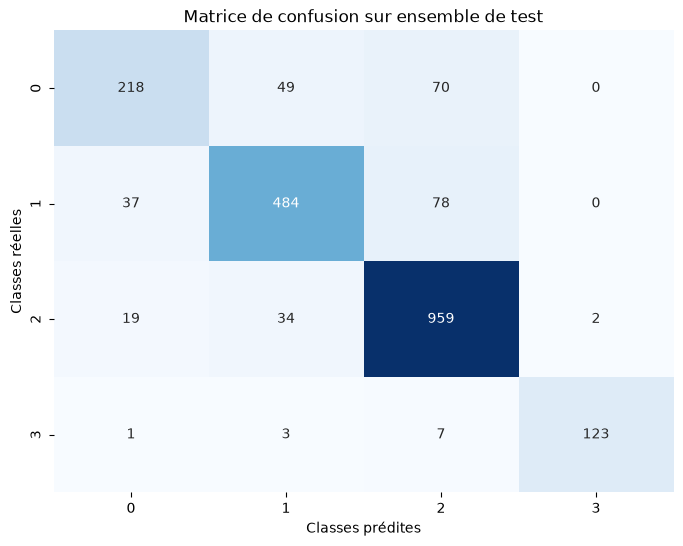

In [35]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)

print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

np.save("CM_FineTuned_EfficientNet.npy", conf_matrix)

9. Réentraînement du model avec class weight

In [40]:
#Calcul des poids

train_ds_not_augmented = image_dataset_from_directory(
    directory=chemin+"/train/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='rgb' 
)


y_train_not_augmented = np.concatenate([labels for images, labels in train_ds_not_augmented], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_not_augmented), y=y_train_not_augmented)
class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

Found 16668 files belonging to 4 classes.
{0: np.float64(1.544477390659748), 1: np.float64(0.8697557921102066), 2: np.float64(0.5138734739178691), 3: np.float64(3.894392523364486)}
